In [1]:
# =============================================================================
# Cell 1: Cài đặt và Import
# =============================================================================
!pip install -q transformers datasets accelerate torch-audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.1 MB/s eta 0:00:00


In [2]:
import os
import glob
import zipfile
import gdown

In [3]:
#https://drive.google.com/file/d/1u96vdkkekd-V5188VSHJJH8hup815snG/view?usp=share_link
file_id = "1u96vdkkekd-V5188VSHJJH8hup815snG"
output_zip = "emodb.zip"

# Tạo link tải trực tiếp từ file_id
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Bước 2: Giải nén file zip
output_folder = "emodb"
os.makedirs(output_folder, exist_ok=True)

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

Downloading...
From (original): https://drive.google.com/uc?id=1u96vdkkekd-V5188VSHJJH8hup815snG
From (redirected): https://drive.google.com/uc?id=1u96vdkkekd-V5188VSHJJH8hup815snG&confirm=t&uuid=435f5699-a410-4fb3-acb2-2e218ba99da5
To: /content/emodb.zip
100%|██████████| 40.1M/40.1M [00:00<00:00, 67.3MB/s]


In [5]:
import shutil # Import the shutil module at the top of your code
folder_path = '/content/emodb'  # Đường dẫn thư mục cần xóa

# Kiểm tra thư mục có tồn tại không rồi xóa
if os.path.exists(folder_path):
    shutil.rmtree(folder_path) # Now you can use shutil.rmtree
    print(f"✅ Đã xóa thư mục: {folder_path}")
else:
    print(f"⚠️ Thư mục không tồn tại: {folder_path}")

✅ Đã xóa thư mục: /content/emodb


/content/EmoDB/Angry/03a01Wa.wav

In [6]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoProcessor, AutoModel, AutoFeatureExtractor, BertTokenizer
import librosa
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện cho Mixed Precision
from torch.cuda.amp import GradScaler, autocast

from torch_audiomentations import Compose, Gain, PolarityInversion, Shift, TimeInversion, AddColoredNoise
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score
import pandas as pd
import os

print("Setup complete!")

Setup complete!


/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = Gain(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/transforms_interface.py:76: FutureWarning: Transforms now expect an `output_type` argument that currently defaults to 'tensor', will default to 'dict' in v0.12, and will be removed in v0.13. Make sure to update your code to something like:
  >>> augment = PolarityInversion(..., output_type='dict')
  >>> augmented_samples = augment(samples).samples
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_audiomentations/core/composition.py:42: FutureWarning: Transforms now expect an `output_type` argum

Initializing...
Size of full_train_df: 474
Full train data: 474 samples
-> Split into: 426 training samples, 48 validation samples
Test data: 61 samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Training:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating (Validation):   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 50: Train Loss=1.3806 | Val Loss=2.6239 | Val Acc=0.7917 | Val F1=0.7609

Training Finished!

--- Final Evaluation on Independent Test Set ---


Evaluating (Test):   0%|          | 0/4 [00:00<?, ?it/s]

Test Set Performance: Loss=2.2627 | Accuracy=0.9672 | F1-Score (Weighted)=0.9669

Classification Report:
              precision    recall  f1-score   support

       Angry       0.95      1.00      0.97        19
       Happy       1.00      0.88      0.93         8
     Neutral       1.00      0.89      0.94         9
        Fear       1.00      1.00      1.00         7
         Sad       1.00      1.00      1.00         5
     Disgust       1.00      1.00      1.00         5
     Boredom       0.89      1.00      0.94         8

    accuracy                           0.97        61
   macro avg       0.98      0.97      0.97        61
weighted avg       0.97      0.97      0.97        61


Generating plots...


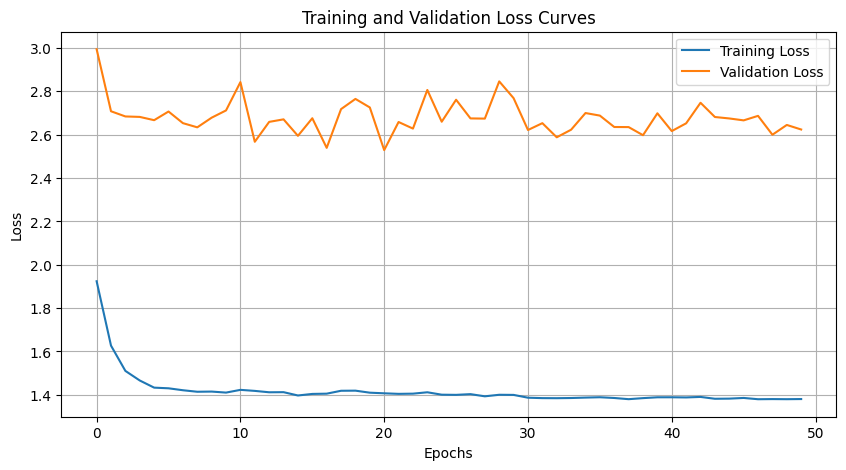

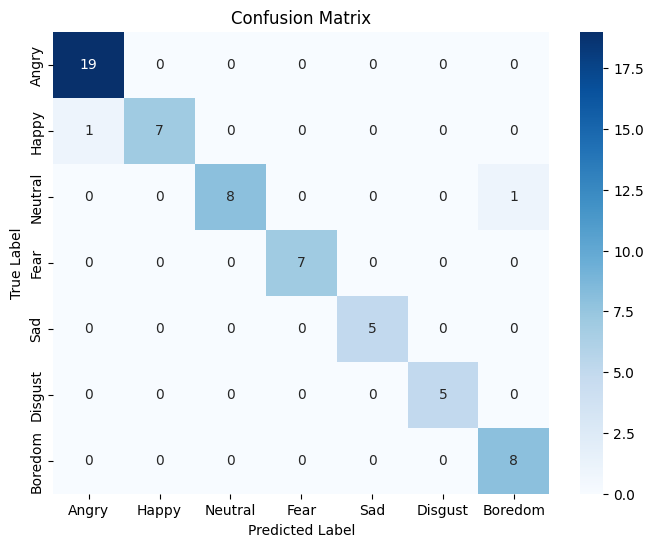

In [7]:
# =============================================================================
# Cell 2: Cấu hình
# =============================================================================
class CFG:
    file_data_train = '/content/EmoDB_data_train.csv'
    file_data_test = '/content/EmoDB_data_test.csv'
    labels = ["Angry", "Happy", "Neutral", "Fear", "Sad", 'Disgust', 'Boredom']
    label2id = {label: i for i, label in enumerate(labels)}
    id2label = {i: label for i, label in enumerate(labels)}
    num_classes = len(labels)

    audio_model_name = "MIT/ast-finetuned-audioset-10-10-0.4593"
    text_model_name = "bert-base-uncased"

    epochs = 50 # Tăng số epoch lên một chút
    batch_size = 16
    learning_rate = 5e-5 # Giảm learning rate một chút để ổn định hơn
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    lambda_cl = 0.5
    lambda_im = 0.5
    lambda_aug = 0.1

    sample_rate = 16000
    duration = 8
    max_text_len = 128

    validation_split_size = 0.1

# =============================================================================
# Cell 3: Các hàm tiện ích (Data Loading, Plotting)
# =============================================================================

def create_dataframe_from_csv(csv_path):
    """
    Tạo một DataFrame từ một tệp CSV.

    Args:
        csv_path (str): Đường dẫn đến tệp CSV.

    Returns:
        pd.DataFrame hoặc None: DataFrame nếu thành công, None nếu có lỗi.
    """
    if not os.path.exists(csv_path):
        print(f"❌ Lỗi: Không tìm thấy tệp tại đường dẫn '{csv_path}'")
        return None

    df = pd.read_csv(csv_path)

    # Đổi tên cột 'filepath' thành 'audio_path' để nhất quán
    if 'filepath' in df.columns:
        df.rename(columns={'filepath': 'audio_path'}, inplace=True)
    elif 'audio_path' not in df.columns:
        print(f"❌ Lỗi: Không tìm thấy cột 'filepath' hoặc 'audio_path' trong tệp {csv_path}")
        return None

    # Các bước xử lý còn lại giữ nguyên
    df['emotion'] = df['audio_path'].apply(lambda path: os.path.basename(os.path.dirname(path)))
    df['emotion_label'] = df['emotion'].map(CFG.label2id)
    df['transcript'] = ""
    df.dropna(subset=['emotion_label'], inplace=True)
    df['emotion_label'] = df['emotion_label'].astype(int)

    return df[["audio_path", "transcript", "emotion_label"]]

def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# =============================================================================
# Cell 4: Lớp Dataset và các hàm tăng cường dữ liệu
# =============================================================================
augmentations = [
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3), Shift(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), PolarityInversion(p=0.3), TimeInversion(p=0.3)]),
    Compose([AddColoredNoise(p=0.3), Shift(p=0.3)]),
    Compose([Gain(min_gain_in_db=-15, max_gain_in_db=5, p=0.3), AddColoredNoise(p=0.3)]),
]

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, audio_processor, augmentations, is_train=True):
        self.df = df
        self.tokenizer = tokenizer
        self.audio_processor = audio_processor
        self.augmentations = augmentations
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        signal, sr = librosa.load(row['audio_path'], sr=CFG.sample_rate)
        target_len = CFG.sample_rate * CFG.duration
        if len(signal) > target_len:
            signal = signal[:target_len]
        else:
            signal = np.pad(signal, (0, target_len - len(signal)), 'constant')

        # Xử lý văn bản
        text = row['transcript']
        tokenized_text = self.tokenizer(text, padding='max_length', truncation=True, max_length=CFG.max_text_len, return_tensors="pt")

        label = torch.tensor(row['emotion_label'], dtype=torch.long)
        aug_idx1 = -1

        if self.is_train:
            signal_tensor_3d = torch.from_numpy(signal).float().unsqueeze(0).unsqueeze(0)

            aug_idx1 = np.random.randint(0, len(self.augmentations))
            aug_idx2 = np.random.randint(0, len(self.augmentations))

            aug_signal1_3d = self.augmentations[aug_idx1](samples=signal_tensor_3d, sample_rate=CFG.sample_rate)
            aug_signal2_3d = self.augmentations[aug_idx2](samples=signal_tensor_3d, sample_rate=CFG.sample_rate)

            aug_signal1 = aug_signal1_3d.squeeze()
            aug_signal2 = aug_signal2_3d.squeeze()

            processed_audio1 = self.audio_processor(aug_signal1, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
            processed_audio2 = self.audio_processor(aug_signal2, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
        else:
            processed_audio1 = self.audio_processor(signal, sampling_rate=CFG.sample_rate, return_tensors="pt").input_values.squeeze(0)
            processed_audio2 = processed_audio1.clone()

        # Dữ liệu trả về cho DataLoader
        return {
            "audio1": processed_audio1,
            "audio2": processed_audio2,
            # Dòng này lấy 'input_ids'
            "text_input_ids": tokenized_text['input_ids'].squeeze(0),
            # Dòng này lấy 'attention_mask'. Đảm bảo không có lỗi đánh máy ở đây.
            "text_attention_mask": tokenized_text['attention_mask'].squeeze(0),
            "label": label,
            "aug_label": torch.tensor(aug_idx1, dtype=torch.long)
        }

# =============================================================================
# Cell 5: Kiến trúc Mô hình và các Hàm Mất mát
# =============================================================================
class AudioMultitaskTransformer(nn.Module):
    def __init__(self, model_name, num_classes, num_aug_classes):
        super().__init__()
        self.ast = AutoModel.from_pretrained(model_name)
        hidden_size = self.ast.config.hidden_size
        self.emotion_head = nn.Linear(hidden_size, num_classes)
        self.aug_head = nn.Linear(hidden_size, num_aug_classes)
        self.projection_head = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, 128))

    def forward(self, audio_features):
        outputs = self.ast(audio_features)
        pooled_output = outputs.last_hidden_state.mean(dim=1)
        emotion_logits = self.emotion_head(pooled_output)
        aug_logits = self.aug_head(pooled_output)
        projection = self.projection_head(pooled_output)
        return emotion_logits, aug_logits, projection

class TextMultitaskTransformer(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.emotion_head = nn.Linear(hidden_size, num_classes)
        self.projection_head = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, 128))

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        emotion_logits = self.emotion_head(pooled_output)
        projection = self.projection_head(pooled_output)
        return emotion_logits, projection

def contrastive_loss(proj1, proj2, temperature=0.1):
    proj1 = F.normalize(proj1, p=2, dim=1)
    proj2 = F.normalize(proj2, p=2, dim=1)
    sim_matrix = torch.matmul(proj1, proj2.T) / temperature
    labels = torch.arange(proj1.size(0)).to(proj1.device)
    loss1 = F.cross_entropy(sim_matrix, labels)
    loss2 = F.cross_entropy(sim_matrix.T, labels)
    return (loss1 + loss2) / 2

def information_maximization_loss(logits):
    softmax_out = F.softmax(logits, dim=1)
    entropy_per_sample = -torch.sum(softmax_out * torch.log(softmax_out + 1e-8), dim=1)
    mean_softmax_out = torch.mean(softmax_out, dim=0)
    entropy_of_mean = -torch.sum(mean_softmax_out * torch.log(mean_softmax_out + 1e-8))
    return entropy_of_mean - torch.mean(entropy_per_sample)

# =============================================================================
# Cell 6: Các hàm Huấn luyện và Đánh giá
# =============================================================================
def train_one_epoch(audio_model, text_model, train_loader, optimizer_audio, optimizer_text, device):
    audio_model.train()
    text_model.train()
    total_loss_audio, total_loss_text = 0, 0

    for batch in tqdm(train_loader, desc="Training"):
        audio1, audio2 = batch['audio1'].to(device), batch['audio2'].to(device)
        input_ids, attention_mask = batch['text_input_ids'].to(device), batch['text_attention_mask'].to(device)
        labels, aug_labels = batch['label'].to(device), batch['aug_label'].to(device)

        # Train Audio Model
        optimizer_audio.zero_grad()
        emotion_logits1, aug_logits1, proj1 = audio_model(audio1)
        emotion_logits2, _, proj2 = audio_model(audio2)
        loss_ser = F.cross_entropy(emotion_logits1, labels)
        loss_cl = contrastive_loss(proj1, proj2)
        loss_im = information_maximization_loss(emotion_logits1)
        loss_aug = F.cross_entropy(aug_logits1, aug_labels)
        audio_loss = loss_ser + CFG.lambda_cl * loss_cl + CFG.lambda_im * loss_im + CFG.lambda_aug * loss_aug
        audio_loss.backward()
        optimizer_audio.step()
        total_loss_audio += audio_loss.item()

        # Train Text Model
        optimizer_text.zero_grad()
        text_logits, _ = text_model(input_ids, attention_mask)
        loss_ser_text = F.cross_entropy(text_logits, labels)
        loss_im_text = information_maximization_loss(text_logits)
        text_loss = loss_ser_text + CFG.lambda_im * loss_im_text
        text_loss.backward()
        optimizer_text.step()
        total_loss_text += text_loss.item()

    return (total_loss_audio + total_loss_text) / (2 * len(train_loader))

def evaluate_and_report(audio_model, text_model, data_loader, device, mode="Validation"):
    audio_model.eval()
    text_model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Evaluating ({mode})"):
            audio, input_ids, attention_mask, labels = batch['audio1'].to(device), batch['text_input_ids'].to(device), batch['text_attention_mask'].to(device), batch['label'].to(device)

            audio_logits, _, _ = audio_model(audio)
            text_logits, _ = text_model(input_ids, attention_mask)

            # Loss tính trên SER loss của cả 2 model
            loss = F.cross_entropy(audio_logits, labels) + F.cross_entropy(text_logits, labels)
            total_loss += loss.item()

            fused_logits = audio_logits + text_logits
            preds = torch.argmax(fused_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_labels, all_preds

# =============================================================================
# Cell 7: Hàm Main
# =============================================================================
def main():
    print("Initializing...")
    # Tải và chuẩn bị dữ liệu
    full_train_df = create_dataframe_from_csv(csv_path = CFG.file_data_train)
    print(f"Size of full_train_df: {len(full_train_df)}") # Add this line to check the DataFrame size
    test_df = create_dataframe_from_csv(csv_path = CFG.file_data_test)

    # Chia tập train thành train và validation
    train_df, val_df = train_test_split(full_train_df, test_size=CFG.validation_split_size, random_state=42, stratify=full_train_df.emotion_label)

    print(f"Full train data: {len(full_train_df)} samples")
    print(f"-> Split into: {len(train_df)} training samples, {len(val_df)} validation samples")
    print(f"Test data: {len(test_df)} samples")

    audio_processor = AutoFeatureExtractor.from_pretrained(CFG.audio_model_name)
    tokenizer = BertTokenizer.from_pretrained(CFG.text_model_name)

    train_dataset = EmotionDataset(train_df, tokenizer, audio_processor, augmentations, is_train=True)
    val_dataset = EmotionDataset(val_df, tokenizer, audio_processor, augmentations, is_train=False)
    test_dataset = EmotionDataset(test_df, tokenizer, audio_processor, augmentations, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

    # Khởi tạo mô hình và optimizer
    audio_model = AudioMultitaskTransformer(CFG.audio_model_name, CFG.num_classes, len(augmentations)).to(CFG.device)
    text_model = TextMultitaskTransformer(CFG.text_model_name, CFG.num_classes).to(CFG.device)
    optimizer_audio = torch.optim.AdamW(audio_model.parameters(), lr=CFG.learning_rate)
    optimizer_text = torch.optim.AdamW(text_model.parameters(), lr=CFG.learning_rate)

    # Lịch sử để vẽ biểu đồ
    train_loss_history, val_loss_history = [], []

    # Vòng lặp huấn luyện chính
    print("\nStarting Training...")
    for epoch in range(CFG.epochs):
        print(f"--- Epoch {epoch+1}/{CFG.epochs} ---")
        train_loss = train_one_epoch(audio_model, text_model, train_loader, optimizer_audio, optimizer_text, CFG.device)
        val_loss, val_acc, val_f1, _, _ = evaluate_and_report(audio_model, text_model, val_loader, CFG.device, mode="Validation")

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f} | Val F1={val_f1:.4f}")

    print("\nTraining Finished!")

    # Đánh giá cuối cùng trên tập test độc lập
    print("\n--- Final Evaluation on Independent Test Set ---")
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate_and_report(audio_model, text_model, test_loader, CFG.device, mode="Test")
    print(f"Test Set Performance: Loss={test_loss:.4f} | Accuracy={test_acc:.4f} | F1-Score (Weighted)={test_f1:.4f}")

    # In ra báo cáo chi tiết
    print("\nClassification Report:")
    class_names = list(CFG.labels)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Vẽ các biểu đồ
    print("\nGenerating plots...")
    plot_loss_curves(train_loss_history, val_loss_history)
    plot_confusion_matrix(y_true, y_pred, class_names)

# =============================================================================
# Cell 8: Chạy chương trình
# =============================================================================
if __name__ == "__main__":
    main()